In [1]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import pandas as pd 
import matplotlib.pyplot as plt
import time




c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv("./data/train.csv")
val = pd.read_csv("./data/val.csv")
test = pd.read_csv("./data/test.csv")

In [3]:
X_val = val[["title", "text"]]
y_val = val["label"]

X_test = test[["title", "text"]]
y_test = test["label"]

<h2>PLM</h2>

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "distilbert-base-uncased"  #lowercase model, ~66M params

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_plm = AutoModel.from_pretrained(MODEL_NAME).to(device)
model_plm.eval()

def get_embeddings(texts, batch_size=128, max_length=256):
    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size].tolist()
            enc = tokenizer(batch, padding=True, truncation=True,
                             max_length=max_length, return_tensors="pt").to(device)
            out = model_plm(**enc)
            cls_embeddings = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\deida\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `

In [9]:
# title+text as one string per row 
train_texts = (train["title"] + " " + train["text"]).values
val_texts   = (val["title"]   + " " + val["text"]).values
test_texts  = (test["title"]  + " " + test["text"]).values

start_time = time.perf_counter()

X_train_emb = get_embeddings(train_texts)
X_val_emb   = get_embeddings(val_texts)
X_test_emb  = get_embeddings(test_texts)

<h2>Logistic Regression</h2>

In [ ]:
clf_plm = LogisticRegression(random_state=42, max_iter=1000)


clf_plm.fit(X_train_emb, train["label"])
end_time = time.perf_counter()

training_time_sec = end_time - start_time

HOURLY_INSTANCE_RATE_USD = 0.23

training_cost_usd = (training_time_sec / 3600.0) * HOURLY_INSTANCE_RATE_USD

In [7]:
y_val_pred = clf_plm.predict(X_val_emb)

acc = accuracy_score(y_val, y_val_pred)
class_report = classification_report(y_val, y_val_pred);


print("Validation Accuracy:", acc )
print("Validation F1 score:", class_report)
print("training time: ",training_time_sec)
print("estimated cost: ",training_cost_usd)

Validation Accuracy: 0.9435994930291508
Validation F1 score:               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5219
           1       0.94      0.93      0.94      4249

    accuracy                           0.94      9468
   macro avg       0.94      0.94      0.94      9468
weighted avg       0.94      0.94      0.94      9468

training time:  8.023141400000895
estimated cost:  0.0005125895894445016


Matrice du confusion

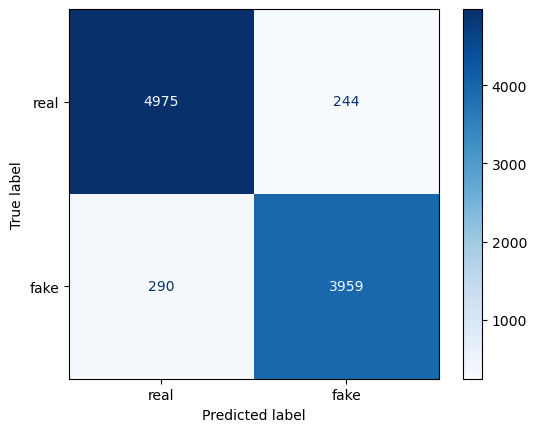

In [8]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
disp.plot(cmap="Blues")
plt.show()